Partie 1 - Exploration et prétraitement des données

1. Analyse exploratoire des données
Dans cette section, nous chargeons le jeu de données, identifions sa structure, vérifions la présence de valeurs manquantes et étudions la distribution de la variable cible ('label').

=== VARIABLES ET TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  60000 non-null  object
 1   label    60000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 937.6+ KB
None

=== APERÇU DES 5 PREMIÈRES LIGNES ===


,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1



=== VALEURS MANQUANTES ===
message    0
label      0
dtype: int64

=== DISTRIBUTION DES CLASSES ===
label
1    53855
0     6145
Name: count, dtype: int64

=== DISTRIBUTION EN % ===
label
1    89.758333
0    10.241667
Name: proportion, dtype: float64


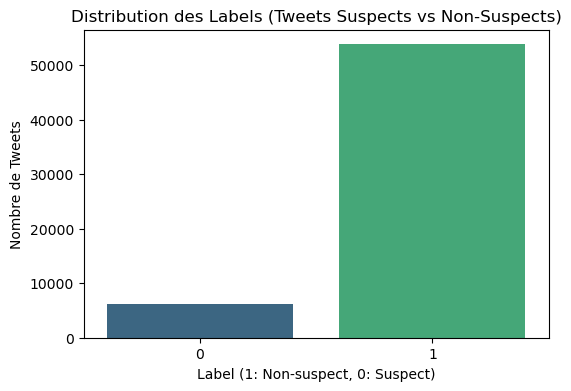

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A. Charger les données avec Pandas
df = pd.read_csv('tweets_suspect.csv', sep=',')

# B. Identifier les variables disponibles
print("=== VARIABLES ET TYPES ===")
print(df.info())

print("\n=== APERÇU DES 5 PREMIÈRES LIGNES ===")
display(df.head())

# C. Vérifier les valeurs manquantes
print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

# D. Étudier la distribution des classes
print("\n=== DISTRIBUTION DES CLASSES ===")
print(df['label'].value_counts())
print("\n=== DISTRIBUTION EN % ===")
print(df['label'].value_counts(normalize=True) * 100)

# E. Produire des visualisations pertinentes
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Distribution des Labels (Tweets Suspects vs Non-Suspects)')
plt.xlabel('Label (1: Non-suspect, 0: Suspect)')
plt.ylabel('Nombre de Tweets')
plt.show()

In [ ]:
2. Prétraitement du texte

Nous allons appliquer un pipeline de nettoyage complet pour standardiser le texte avant sa vectorisation.

In [13]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargement des dépendances NLTK requises
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\1\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:

# Initialisation des outils
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def pipeline_pretraitement(text):
    # 1. Conversion en minuscules
    text = text.lower()
    
    # 2. Suppression des URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Suppression des mentions (@) et hashtags (#) courantes sur Twitter
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # 4. Suppression des caractères spéciaux et de la ponctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Extraction des mots (Tokenisation simple)
    words = text.split()
    
    # 5. Suppression des stop words + Lemmatisation
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Reconstruction du texte nettoyé
    return " ".join(cleaned_words)

# Application du traitement sur l'ensemble du jeu de données
print("Application du prétraitement sur les 60 000 tweets...")
df['clean_message'] = df['message'].apply(pipeline_pretraitement)

# Affichage du résultat comparatif demandé
print("\n=== COMPARAISON AVANT / APRÈS PRÉTRAITEMENT ===")
display(df[['message', 'clean_message']].head(10))

Application du prétraitement sur les 60 000 tweets...

=== COMPARAISON AVANT / APRÈS PRÉTRAITEMENT ===


,message,clean_message
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats bummer shoulda got david carr third...
1,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see
5,@Kwesidei not the whole crew,whole crew
6,Need a hug,need hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time see yes rain bit bit lol im fine...
8,@Tatiana_K nope they didn't have it,nope didnt
9,@twittera que me muera ?,que muera
